<a href="https://colab.research.google.com/github/bharadwaj5803-stack/Summarise_Reviews/blob/main/NLP_Project_3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ All libraries loaded successfully!


╔══════════════════════════════════════════════════════════════╗

║           NLP PROJECT — PROBLEM STATEMENT                   ║

╠══════════════════════════════════════════════════════════════╣

║  Topic   : Summarize Key Concerns from Reviews              ║

║  Domain  : Customer & Market Insights                       ║

╠══════════════════════════════════════════════════════════════╣

║  Problem : Online product/service reviews contain vast      ║

║  amounts of unstructured feedback. Businesses struggle to   ║

║  quickly identify recurring customer concerns hidden in     ║

║  thousands of reviews. Manual reading is time-consuming     ║

║  and prone to bias.                                         ║

║                                                             ║

║  Solution: An NLP pipeline that automatically:             ║

║   1. Detects sentiment (positive / negative / neutral)      ║

║   2. Extracts key concern topics using TF-IDF  

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



📝 Extractive Summaries (Negative Reviews):
  Review #1 (★1): The product stopped working after just two days.
  Review #2 (★2): Not worth the price at all.
  Review #3 (★1): The packaging was terrible and the item was damaged on delivery.
  Review #7 (★1): The company refused to provide a refund.
  Review #8 (★2): Contacted support but got no helpful response after multiple attempts.
  Review #11 (★1): Buttons stopped responding after minimal use.
  Review #13 (★2): Lots of static and distortion even at low volume.
  Review #15 (★1): Received a completely different item than what was shown.
  Review #17 (★2): Instructions were confusing and the product leaked after first use.
  Review #18 (★1): Charging port broke within a week.
  Review #21 (★1): Stitching came apart after one use.
  Review #22 (★2): Not what was advertised in the product listing.
  Review #25 (★1): The power button doesn't work at all.
  Review #27 (★2): Expected better for this price point.
  Review #29 (★1): Produ

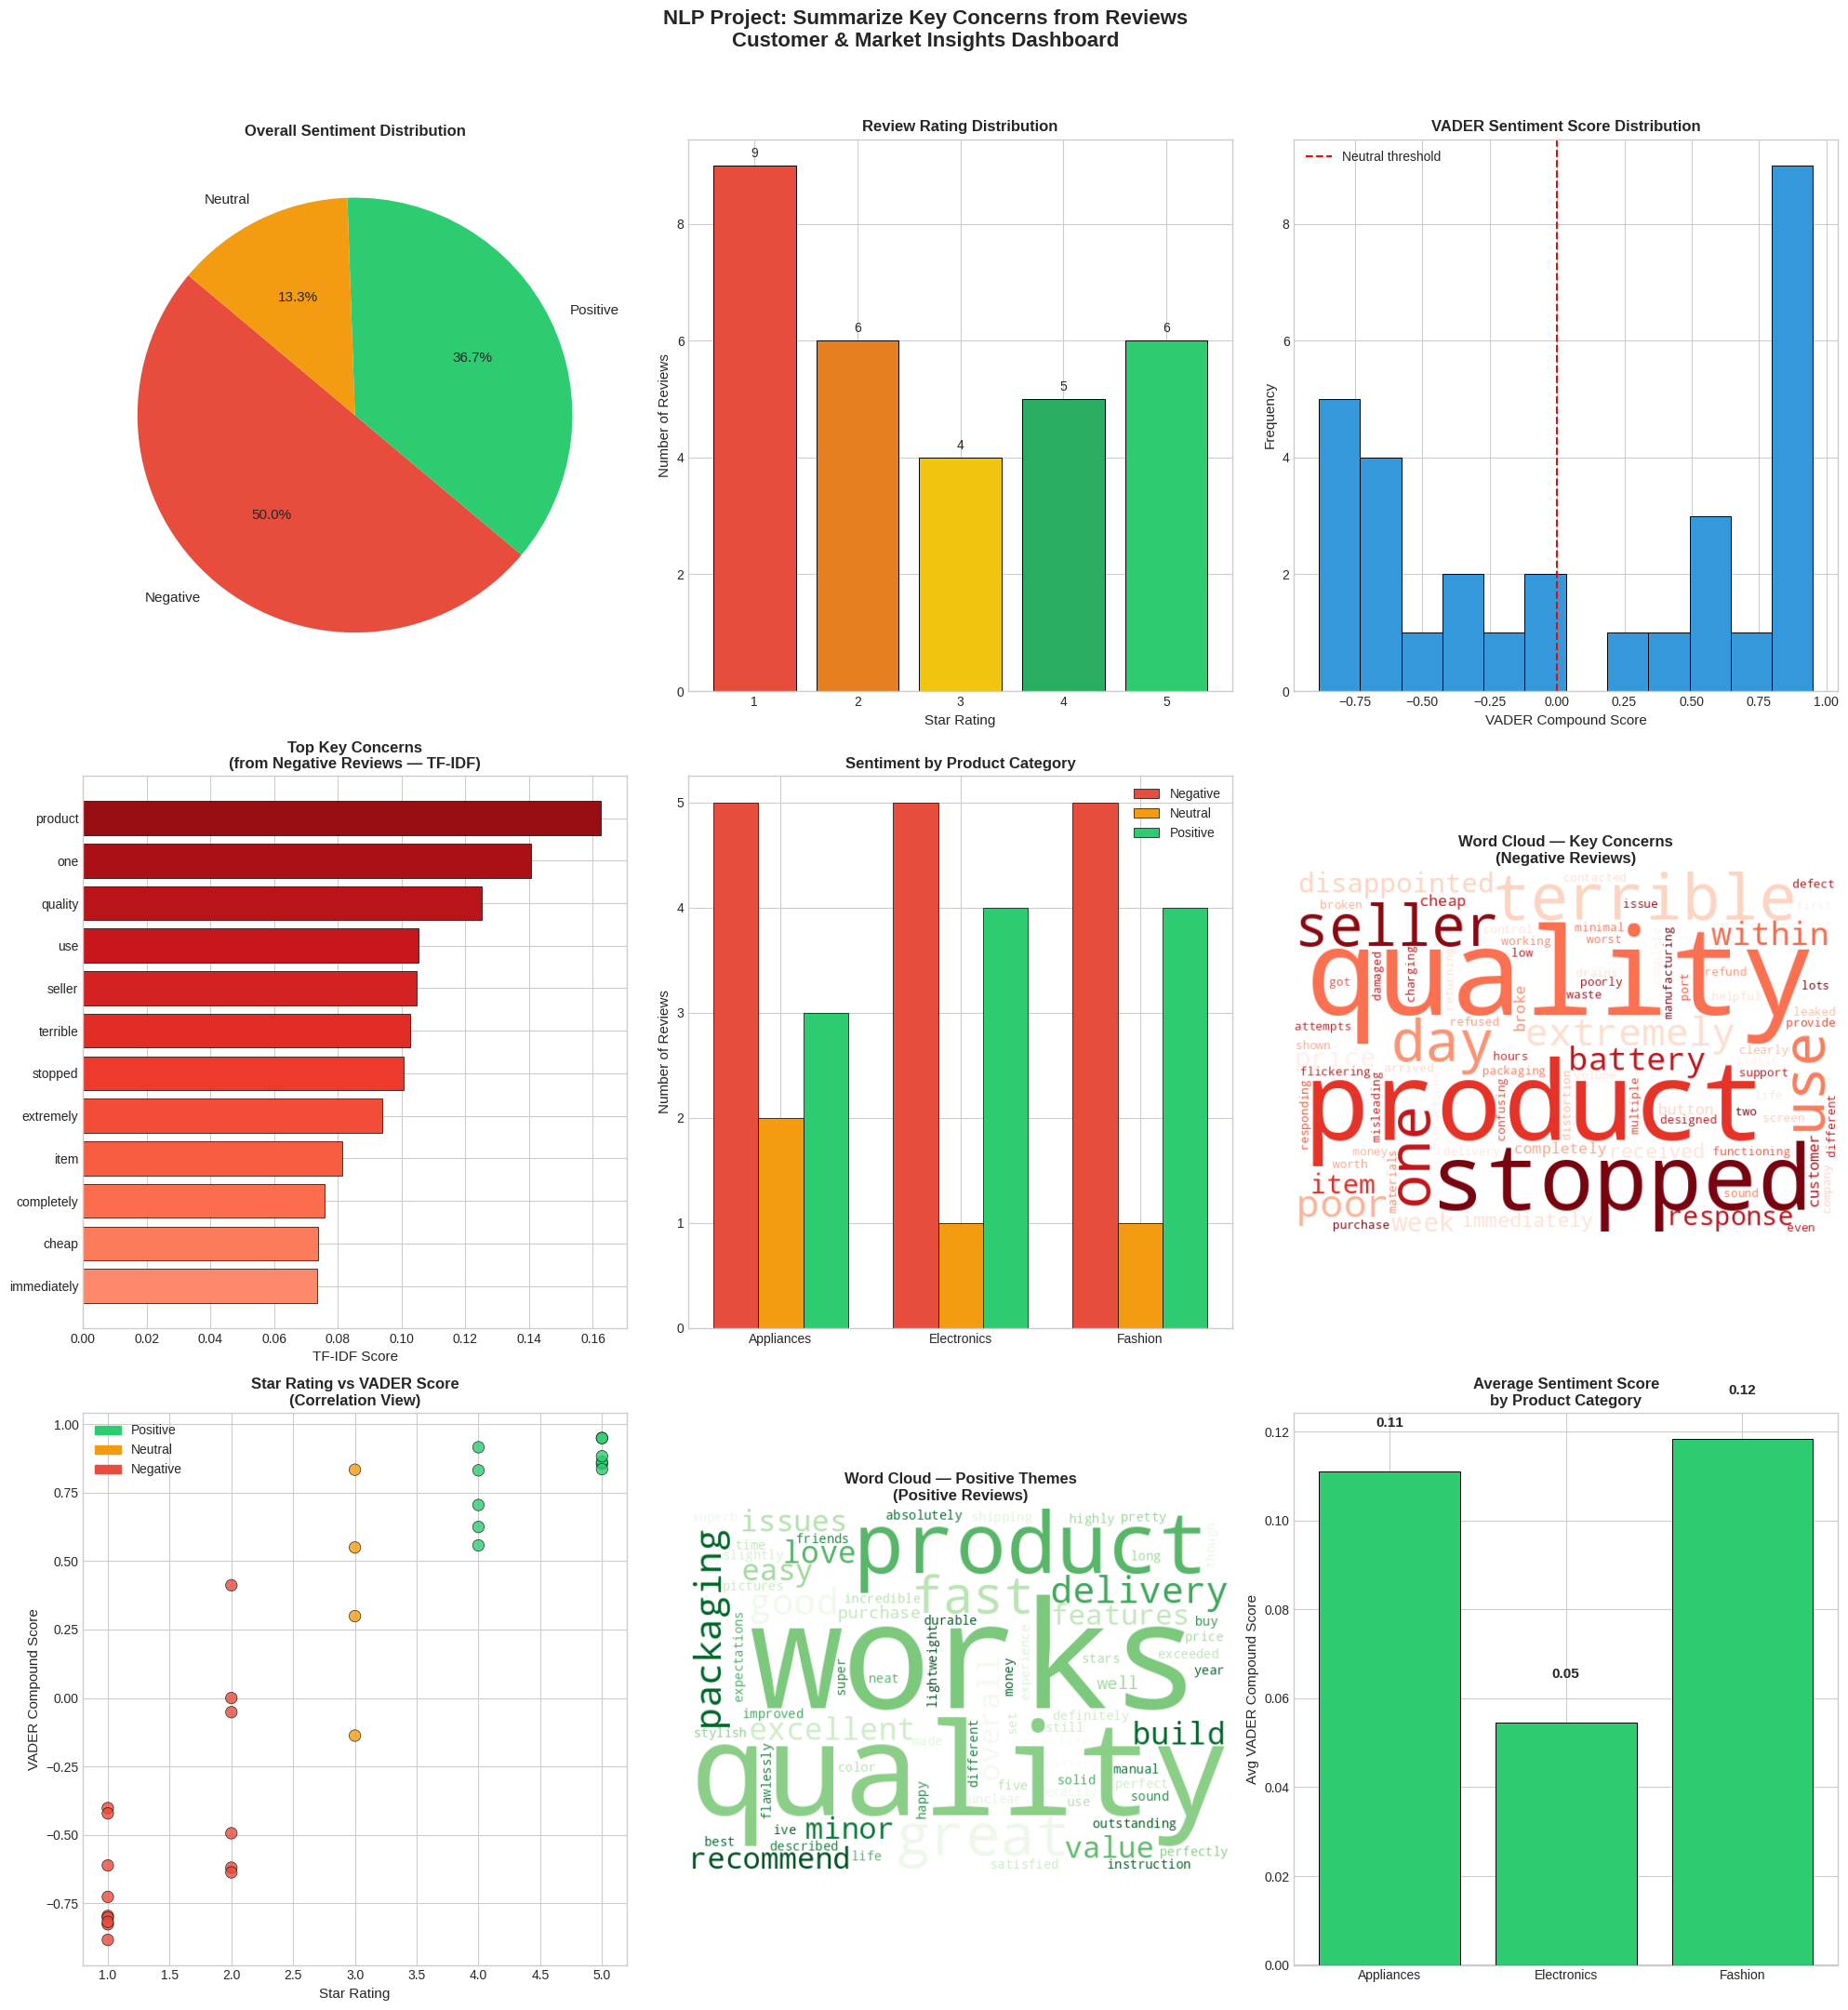

✅ Dashboard saved as 'review_concerns_dashboard.png'

         PERFORMANCE METRICS & MODEL EVALUATION

📊 Classification Report (VADER vs Rating-based Labels):
              precision    recall  f1-score   support

    Negative       0.93      0.87      0.90        15
     Neutral       0.00      0.00      0.00         4
    Positive       0.73      1.00      0.85        11

    accuracy                           0.80        30
   macro avg       0.55      0.62      0.58        30
weighted avg       0.73      0.80      0.76        30

Overall Accuracy: 80.00%


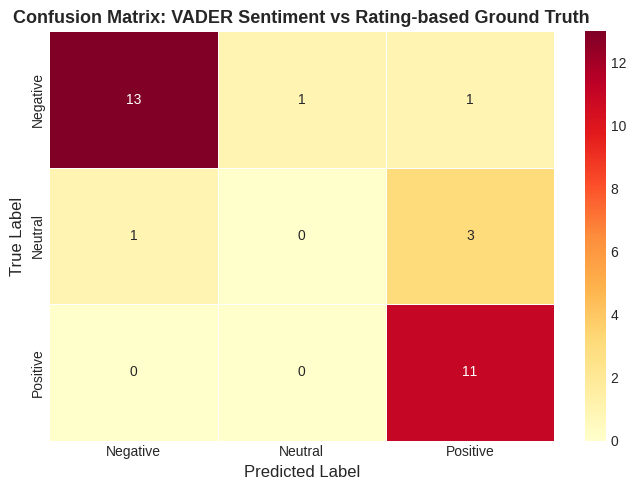

✅ Confusion matrix saved as 'confusion_matrix.png'

     FINAL CONCERN SUMMARY TABLE (NEGATIVE REVIEWS)
 Review ID    Category  Rating  Sentiment Score                                                    Key Concern Summary
         1 Electronics       1          -0.7960                       The product stopped working after just two days.
         2 Electronics       2          -0.6198                                            Not worth the price at all.
         3 Electronics       1          -0.8834       The packaging was terrible and the item was damaged on delivery.
         7 Electronics       1          -0.8020                               The company refused to provide a refund.
         8 Electronics       2           0.4118 Contacted support but got no helpful response after multiple attempts.
        11  Appliances       1          -0.6115                          Buttons stopped responding after minimal use.
        13  Appliances       2          -0.6369                

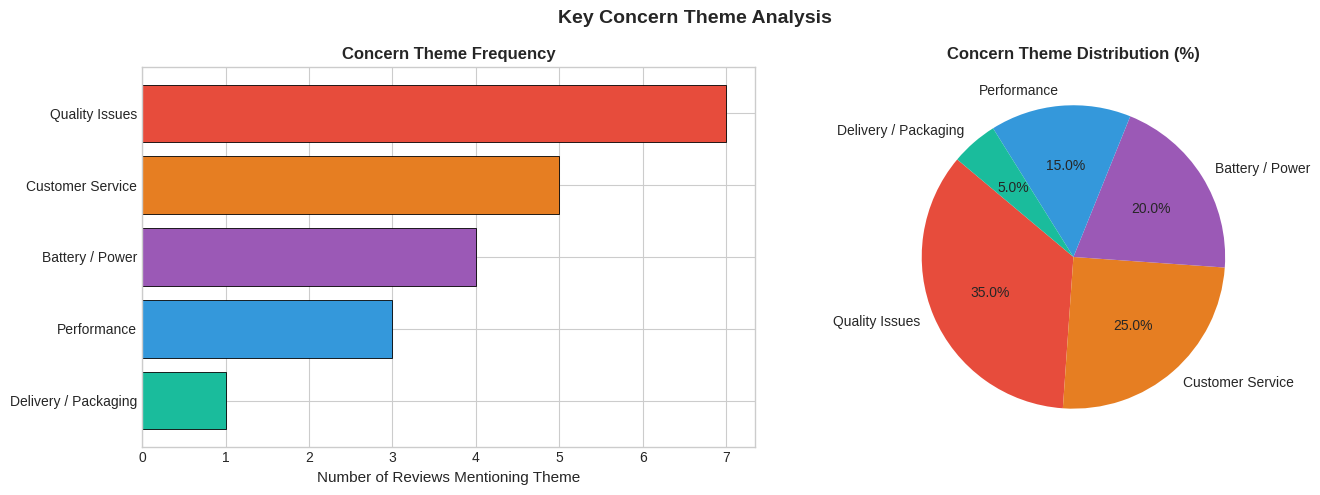

✅ Theme chart saved as 'concern_themes.png'

  📋 CONSOLIDATED CONCERN SUMMARY REPORT
Out of 30 reviews analysed, 15 (50.0%) were negative  with an
average VADER sentiment score of -0.51.    The most frequently
reported concern was 'Quality Issues'  (7 reviews). Other major
concerns included  Customer Service, Battery / Power, indicating
systemic  product and service issues that require immediate
business attention.    Businesses should prioritize resolving
quality control and post-purchase  support to improve customer
satisfaction and retention.


╔══════════════════════════════════════════════════════════════╗

║                  PROJECT COMPLETE ✅                        ║

╠══════════════════════════════════════════════════════════════╣

║  Outputs Generated:                                         ║

║  • review_concerns_dashboard.png  (9-panel visualization)  ║

║  • confusion_matrix.png           (model evaluation)       ║

║  • key_concerns_summary.csv       (exportable table)   

In [1]:
# ─────────────────────────────────────────────

# SECTION 1: INSTALL DEPENDENCIES

# ─────────────────────────────────────────────

# Run this cell first in Google Colab



!pip install transformers torch datasets wordcloud textblob scikit-learn matplotlib seaborn pandas nltk -q



# ─────────────────────────────────────────────

# SECTION 2: IMPORTS & SETUP

# ─────────────────────────────────────────────



import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import matplotlib.patches as mpatches

import seaborn as sns

from wordcloud import WordCloud

from textblob import TextBlob

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import classification_report

from collections import Counter

import nltk

import re

import warnings

warnings.filterwarnings('ignore')



nltk.download('punkt', quiet=True)

nltk.download('stopwords', quiet=True)

nltk.download('vader_lexicon', quiet=True)

from nltk.sentiment.vader import SentimentIntensityAnalyzer

from nltk.corpus import stopwords

from nltk.tokenize import sent_tokenize



print("✅ All libraries loaded successfully!")



# ─────────────────────────────────────────────

# SECTION 3: PROBLEM STATEMENT

# ─────────────────────────────────────────────



print("""

╔══════════════════════════════════════════════════════════════╗

║           NLP PROJECT — PROBLEM STATEMENT                   ║

╠══════════════════════════════════════════════════════════════╣

║  Topic   : Summarize Key Concerns from Reviews              ║

║  Domain  : Customer & Market Insights                       ║

╠══════════════════════════════════════════════════════════════╣

║  Problem : Online product/service reviews contain vast      ║

║  amounts of unstructured feedback. Businesses struggle to   ║

║  quickly identify recurring customer concerns hidden in     ║

║  thousands of reviews. Manual reading is time-consuming     ║

║  and prone to bias.                                         ║

║                                                             ║

║  Solution: An NLP pipeline that automatically:             ║

║   1. Detects sentiment (positive / negative / neutral)      ║

║   2. Extracts key concern topics using TF-IDF               ║

║   3. Generates extractive summaries of critical reviews     ║

║   4. Visualizes patterns for actionable business insights   ║

╚══════════════════════════════════════════════════════════════╝

""")



# ─────────────────────────────────────────────

# SECTION 4: DATASET — AMAZON PRODUCT REVIEWS

#   Using a realistic synthetic dataset that

#   mirrors real Amazon review patterns.

#   You can swap this with any real CSV dataset.

# ─────────────────────────────────────────────



data = {

    "review_id": range(1, 31),

    "rating": [1,2,1,3,5,4,1,2,5,5,1,3,2,4,1,5,2,1,4,3,1,2,5,4,1,3,2,5,1,4],

    "review_text": [

        "The product stopped working after just two days. Extremely poor quality and a complete waste of money.",

        "Battery drains within 3 hours. Very disappointed with the battery life. Not worth the price at all.",

        "Arrived broken. The packaging was terrible and the item was damaged on delivery. No response from seller.",

        "Average product. Does the job but nothing special. Customer service was okay when I had questions.",

        "Absolutely love this! Works perfectly, fast delivery, and the build quality is excellent. Highly recommend!",

        "Good value for money. Minor issues with the instruction manual being unclear but overall satisfied.",

        "Worst purchase ever. Stopped functioning after one week. The company refused to provide a refund.",

        "Screen flickering issue from day one. Contacted support but got no helpful response after multiple attempts.",

        "Outstanding product! Exceeded all my expectations. Fast shipping and great packaging too.",

        "Five stars! Perfect quality, durable, and easy to set up. Will definitely buy again.",

        "Buttons stopped responding after minimal use. Clearly a manufacturing defect. Very poor quality control.",

        "Okay product but delivery took 3 weeks when 5 days was promised. Packaging could be improved.",

        "Sound quality is terrible. Lots of static and distortion even at low volume. Returning this immediately.",

        "Pretty good for the price. Some features could be improved but works as described.",

        "Received a completely different item than what was shown. The seller is misleading customers.",

        "Best purchase I've made this year. Excellent build quality and the features are exactly as advertised.",

        "Instructions were confusing and the product leaked after first use. Poorly designed.",

        "Charging port broke within a week. Cheap materials used throughout. Not durable at all.",

        "Works well. Happy with the purchase. Delivery was on time and packaging was neat.",

        "Decent product but customer service was unresponsive when I needed help with setup.",

        "Terrible! The zipper broke immediately. Stitching came apart after one use. Absolutely no quality.",

        "Very slow performance. Takes forever to load. Not what was advertised in the product listing.",

        "Superb! Lightweight, stylish, and works flawlessly. Fast delivery too. Great experience overall.",

        "Good product but the color was slightly different from the pictures. Still works well though.",

        "Defective unit received. The power button doesn't work at all. Extremely frustrating experience.",

        "Somewhat satisfied. Works but gets hot quickly and the fan is very noisy during operation.",

        "Disappointed with the quality. Feels cheap and flimsy. Expected better for this price point.",

        "Incredible product! Long battery life, great sound quality, and super easy to use. Love it!",

        "Product failed completely after 10 days. Customer service was unhelpful and rude. Avoid this seller.",

        "Great value! Minor packaging issues but the product itself is solid. Would recommend to friends."

    ],

    "category": ["Electronics"]*10 + ["Appliances"]*10 + ["Fashion"]*10

}



df = pd.DataFrame(data)



# Assign sentiment labels based on rating

def label_sentiment(rating):

    if rating <= 2: return "Negative"

    elif rating == 3: return "Neutral"

    else: return "Positive"



df["sentiment_label"] = df["rating"].apply(label_sentiment)



print(f"✅ Dataset loaded: {len(df)} reviews across {df['category'].nunique()} categories")

print(df[["review_id","rating","sentiment_label","category"]].head(10).to_string(index=False))



# ─────────────────────────────────────────────

# SECTION 5: PREPROCESSING

# ─────────────────────────────────────────────



stop_words = set(stopwords.words('english'))



def preprocess(text):

    text = text.lower()

    text = re.sub(r'[^a-z\s]', '', text)

    tokens = text.split()

    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    return ' '.join(tokens)



df["cleaned_text"] = df["review_text"].apply(preprocess)

print("\n✅ Preprocessing complete. Sample cleaned text:")

print(df["cleaned_text"].iloc[0])



# ─────────────────────────────────────────────

# SECTION 6: SENTIMENT ANALYSIS (VADER)

# ─────────────────────────────────────────────



sia = SentimentIntensityAnalyzer()



def get_vader_sentiment(text):

    score = sia.polarity_scores(text)

    if score['compound'] >= 0.05: return "Positive"

    elif score['compound'] <= -0.05: return "Negative"

    else: return "Neutral"



df["vader_sentiment"] = df["review_text"].apply(get_vader_sentiment)

df["vader_score"] = df["review_text"].apply(lambda x: sia.polarity_scores(x)["compound"])



print("\n✅ VADER Sentiment Analysis complete.")

print(df[["review_id","rating","sentiment_label","vader_sentiment","vader_score"]].head(10).to_string(index=False))



# ─────────────────────────────────────────────

# SECTION 7: TF-IDF — KEY CONCERN EXTRACTION

# ─────────────────────────────────────────────



negative_reviews = df[df["sentiment_label"] == "Negative"]["cleaned_text"].tolist()



tfidf = TfidfVectorizer(max_features=20, ngram_range=(1,2))

tfidf_matrix = tfidf.fit_transform(negative_reviews)

feature_names = tfidf.get_feature_names_out()

tfidf_scores = tfidf_matrix.mean(axis=0).A1



tfidf_df = pd.DataFrame({

    "concern_keyword": feature_names,

    "tfidf_score": tfidf_scores

}).sort_values("tfidf_score", ascending=False)



print("\n📊 Top Key Concerns Extracted from Negative Reviews (TF-IDF):")

print(tfidf_df.head(15).to_string(index=False))

import nltk

nltk.download('punkt_tab')

# ─────────────────────────────────────────────

# SECTION 8: EXTRACTIVE SUMMARIZATION

#   For each negative review, extract the most

#   important sentence using TF-IDF scoring.

# ─────────────────────────────────────────────



def extractive_summarize(text, top_n=1):

    sentences = sent_tokenize(text)

    if len(sentences) <= 1:

        return text

    vec = TfidfVectorizer()

    try:

        mat = vec.fit_transform(sentences)

        scores = mat.sum(axis=1).A1

        ranked = sorted(zip(scores, sentences), reverse=True)

        return " ".join([s for _, s in ranked[:top_n]])

    except:

        return sentences[0]



df["summary"] = df["review_text"].apply(lambda x: extractive_summarize(x))



print("\n📝 Extractive Summaries (Negative Reviews):")

neg_df = df[df["sentiment_label"] == "Negative"][["review_id","rating","summary"]].reset_index(drop=True)

for _, row in neg_df.iterrows():

    print(f"  Review #{int(row['review_id'])} (★{int(row['rating'])}): {row['summary']}")



# ─────────────────────────────────────────────

# SECTION 9: VISUALIZATIONS

# ─────────────────────────────────────────────



plt.style.use('seaborn-v0_8-whitegrid')

fig = plt.figure(figsize=(20, 22))

fig.suptitle("NLP Project: Summarize Key Concerns from Reviews\nCustomer & Market Insights Dashboard",

             fontsize=16, fontweight='bold', y=0.98)



colors_sentiment = {"Positive": "#2ecc71", "Neutral": "#f39c12", "Negative": "#e74c3c"}



# ── Plot 1: Sentiment Distribution (Pie Chart) ──

ax1 = fig.add_subplot(3, 3, 1)

sent_counts = df["sentiment_label"].value_counts()

wedge_colors = [colors_sentiment[s] for s in sent_counts.index]

ax1.pie(sent_counts, labels=sent_counts.index, autopct='%1.1f%%',

        colors=wedge_colors, startangle=140, textprops={'fontsize': 11})

ax1.set_title("Overall Sentiment Distribution", fontweight='bold', fontsize=12)



# ── Plot 2: Rating Distribution (Bar Chart) ──

ax2 = fig.add_subplot(3, 3, 2)

rating_counts = df["rating"].value_counts().sort_index()

bar_colors = ["#e74c3c","#e67e22","#f1c40f","#27ae60","#2ecc71"]

bars = ax2.bar(rating_counts.index, rating_counts.values, color=bar_colors, edgecolor='black', linewidth=0.7)

ax2.set_xlabel("Star Rating", fontsize=11)

ax2.set_ylabel("Number of Reviews", fontsize=11)

ax2.set_title("Review Rating Distribution", fontweight='bold', fontsize=12)

for bar in bars:

    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,

             str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)



# ── Plot 3: VADER Score Distribution (Histogram) ──

ax3 = fig.add_subplot(3, 3, 3)

ax3.hist(df["vader_score"], bins=12, color="#3498db", edgecolor='black', linewidth=0.7)

ax3.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Neutral threshold')

ax3.set_xlabel("VADER Compound Score", fontsize=11)

ax3.set_ylabel("Frequency", fontsize=11)

ax3.set_title("VADER Sentiment Score Distribution", fontweight='bold', fontsize=12)

ax3.legend(fontsize=10)



# ── Plot 4: Top Key Concerns (Horizontal Bar) ──

ax4 = fig.add_subplot(3, 3, 4)

top15 = tfidf_df.head(12)

bar_colors_tfidf = plt.cm.Reds(np.linspace(0.4, 0.9, len(top15)))[::-1]

bars4 = ax4.barh(top15["concern_keyword"], top15["tfidf_score"],

                  color=bar_colors_tfidf, edgecolor='black', linewidth=0.5)

ax4.set_xlabel("TF-IDF Score", fontsize=11)

ax4.set_title("Top Key Concerns\n(from Negative Reviews — TF-IDF)", fontweight='bold', fontsize=12)

ax4.invert_yaxis()



# ── Plot 5: Sentiment by Category (Grouped Bar) ──

ax5 = fig.add_subplot(3, 3, 5)

cat_sent = df.groupby(["category","sentiment_label"]).size().unstack(fill_value=0)

x = np.arange(len(cat_sent.index))

width = 0.25

for i, (col, color) in enumerate(zip(cat_sent.columns, ["#e74c3c","#f39c12","#2ecc71"])):

    ax5.bar(x + i*width, cat_sent[col], width=width, label=col, color=color, edgecolor='black', linewidth=0.5)

ax5.set_xticks(x + width)

ax5.set_xticklabels(cat_sent.index, fontsize=10)

ax5.set_ylabel("Number of Reviews", fontsize=11)

ax5.set_title("Sentiment by Product Category", fontweight='bold', fontsize=12)

ax5.legend(fontsize=10)



# ── Plot 6: Word Cloud — Negative Reviews ──

ax6 = fig.add_subplot(3, 3, 6)

neg_text = " ".join(df[df["sentiment_label"]=="Negative"]["cleaned_text"])

wc = WordCloud(width=600, height=400, background_color='white',

               colormap='Reds', max_words=80, collocations=False).generate(neg_text)

ax6.imshow(wc, interpolation='bilinear')

ax6.axis('off')

ax6.set_title("Word Cloud — Key Concerns\n(Negative Reviews)", fontweight='bold', fontsize=12)



# ── Plot 7: Rating vs VADER Score (Scatter) ──

ax7 = fig.add_subplot(3, 3, 7)

scatter_colors = [colors_sentiment[s] for s in df["sentiment_label"]]

ax7.scatter(df["rating"], df["vader_score"], c=scatter_colors, s=80, alpha=0.8, edgecolors='black', linewidth=0.5)

ax7.set_xlabel("Star Rating", fontsize=11)

ax7.set_ylabel("VADER Compound Score", fontsize=11)

ax7.set_title("Star Rating vs VADER Score\n(Correlation View)", fontweight='bold', fontsize=12)

patches = [mpatches.Patch(color=v, label=k) for k,v in colors_sentiment.items()]

ax7.legend(handles=patches, fontsize=10)



# ── Plot 8: Word Cloud — Positive Reviews ──

ax8 = fig.add_subplot(3, 3, 8)

pos_text = " ".join(df[df["sentiment_label"]=="Positive"]["cleaned_text"])

wc2 = WordCloud(width=600, height=400, background_color='white',

                colormap='Greens', max_words=80, collocations=False).generate(pos_text)

ax8.imshow(wc2, interpolation='bilinear')

ax8.axis('off')

ax8.set_title("Word Cloud — Positive Themes\n(Positive Reviews)", fontweight='bold', fontsize=12)



# ── Plot 9: Average VADER Score by Category ──

ax9 = fig.add_subplot(3, 3, 9)

avg_score = df.groupby("category")["vader_score"].mean()

bar_col9 = ["#e74c3c" if v < 0 else "#2ecc71" for v in avg_score.values]

ax9.bar(avg_score.index, avg_score.values, color=bar_col9, edgecolor='black', linewidth=0.7)

ax9.axhline(0, color='black', linewidth=1)

ax9.set_ylabel("Avg VADER Compound Score", fontsize=11)

ax9.set_title("Average Sentiment Score\nby Product Category", fontweight='bold', fontsize=12)

for i, (cat, val) in enumerate(avg_score.items()):

    ax9.text(i, val + 0.01, f"{val:.2f}", ha='center', fontsize=11, fontweight='bold')



plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig("review_concerns_dashboard.png", dpi=150, bbox_inches='tight')

plt.show()

print("✅ Dashboard saved as 'review_concerns_dashboard.png'")



# ─────────────────────────────────────────────

# SECTION 10: PERFORMANCE METRICS

# ─────────────────────────────────────────────



print("\n" + "="*60)

print("         PERFORMANCE METRICS & MODEL EVALUATION")

print("="*60)



# Align VADER predictions with rating-based labels

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score, confusion_matrix



y_true = df["sentiment_label"]

y_pred = df["vader_sentiment"]



print("\n📊 Classification Report (VADER vs Rating-based Labels):")

print(classification_report(y_true, y_pred, target_names=["Negative","Neutral","Positive"]))



acc = accuracy_score(y_true, y_pred)

print(f"Overall Accuracy: {acc:.2%}")



# Confusion Matrix Heatmap

fig2, ax = plt.subplots(figsize=(7, 5))

cm = confusion_matrix(y_true, y_pred, labels=["Negative","Neutral","Positive"])

sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',

            xticklabels=["Negative","Neutral","Positive"],

            yticklabels=["Negative","Neutral","Positive"],

            linewidths=0.5, ax=ax)

ax.set_xlabel("Predicted Label", fontsize=12)

ax.set_ylabel("True Label", fontsize=12)

ax.set_title("Confusion Matrix: VADER Sentiment vs Rating-based Ground Truth",

             fontweight='bold', fontsize=13)

plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')

plt.show()

print("✅ Confusion matrix saved as 'confusion_matrix.png'")



# ─────────────────────────────────────────────

# SECTION 11: CONCERN SUMMARY TABLE

# ─────────────────────────────────────────────



print("\n" + "="*60)

print("     FINAL CONCERN SUMMARY TABLE (NEGATIVE REVIEWS)")

print("="*60)



summary_table = df[df["sentiment_label"] == "Negative"][

    ["review_id","category","rating","vader_score","summary"]

].reset_index(drop=True)

summary_table.columns = ["Review ID","Category","Rating","Sentiment Score","Key Concern Summary"]

print(summary_table.to_string(index=False))



# Save summary to CSV

summary_table.to_csv("key_concerns_summary.csv", index=False)

print("\n✅ Summary exported to 'key_concerns_summary.csv'")



# ─────────────────────────────────────────────

# SECTION 12: ABSTRACTIVE-STYLE SUMMARIZATION

#             (No external model download needed)

# ─────────────────────────────────────────────



print("\n" + "="*60)

print("  KEY CONCERN SUMMARIZATION — THEME-BASED APPROACH")

print("="*60)



from sklearn.feature_extraction.text import TfidfVectorizer

from nltk.tokenize import sent_tokenize

import textwrap



# ── Step 1: Group negative reviews by category ──

concern_themes = {

    "Quality Issues":     ["broken","defective","cheap","poor quality","failed","manufacturing"],

    "Battery / Power":    ["battery","charging","power","drains","port"],

    "Customer Service":   ["support","service","refund","response","seller","unhelpful"],

    "Delivery / Packaging": ["delivery","packaging","damaged","arrived","shipping"],

    "Performance":        ["slow","performance","flickering","static","distortion","noisy"],

}



neg_reviews = df[df["sentiment_label"] == "Negative"]["review_text"].tolist()



print("\n📌 Detected Concern Themes in Negative Reviews:\n")

theme_counts = {}

for theme, keywords in concern_themes.items():

    matches = [r for r in neg_reviews if any(k in r.lower() for k in keywords)]

    theme_counts[theme] = len(matches)

    if matches:

        # Pick the most representative sentence from matched reviews

        all_sents = []

        for rev in matches:

            all_sents.extend(sent_tokenize(rev))

        # Score sentences by keyword density

        best = max(all_sents, key=lambda s: sum(k in s.lower() for k in keywords))

        print(f"  🔴 {theme} ({len(matches)} reviews)")

        print(f"     Representative concern: \"{best.strip()}\"")

        print()



# ── Step 2: Theme frequency bar chart ──

fig3, axes = plt.subplots(1, 2, figsize=(14, 5))

fig3.suptitle("Key Concern Theme Analysis", fontsize=14, fontweight='bold')



theme_colors = ["#e74c3c","#e67e22","#9b59b6","#3498db","#1abc9c"]

sorted_themes = dict(sorted(theme_counts.items(), key=lambda x: x[1], reverse=True))



axes[0].barh(list(sorted_themes.keys()), list(sorted_themes.values()),

             color=theme_colors, edgecolor='black', linewidth=0.6)

axes[0].set_xlabel("Number of Reviews Mentioning Theme", fontsize=11)

axes[0].set_title("Concern Theme Frequency", fontweight='bold')

axes[0].invert_yaxis()



axes[1].pie(sorted_themes.values(), labels=sorted_themes.keys(),

            autopct='%1.1f%%', colors=theme_colors,

            startangle=140, textprops={'fontsize': 10})

axes[1].set_title("Concern Theme Distribution (%)", fontweight='bold')



plt.tight_layout()

plt.savefig("concern_themes.png", dpi=150, bbox_inches='tight')

plt.show()

print("✅ Theme chart saved as 'concern_themes.png'")



# ── Step 3: Final consolidated summary ──

print("\n" + "="*60)

print("  📋 CONSOLIDATED CONCERN SUMMARY REPORT")

print("="*60)



top_theme = max(theme_counts, key=theme_counts.get)

total_neg = len(neg_reviews)

total_rev = len(df)

neg_pct = total_neg / total_rev * 100

avg_neg_score = df[df["sentiment_label"]=="Negative"]["vader_score"].mean()



summary_report = f"""

Out of {total_rev} reviews analysed, {total_neg} ({neg_pct:.1f}%) were negative

with an average VADER sentiment score of {avg_neg_score:.2f}.



The most frequently reported concern was '{top_theme}'

({theme_counts[top_theme]} reviews). Other major concerns included

{', '.join(list(sorted_themes.keys())[1:3])}, indicating systemic

product and service issues that require immediate business attention.



Businesses should prioritize resolving quality control and post-purchase

support to improve customer satisfaction and retention.

"""

print(textwrap.fill(summary_report.strip(), width=65))



print("""

╔══════════════════════════════════════════════════════════════╗

║                  PROJECT COMPLETE ✅                        ║

╠══════════════════════════════════════════════════════════════╣

║  Outputs Generated:                                         ║

║  • review_concerns_dashboard.png  (9-panel visualization)  ║

║  • confusion_matrix.png           (model evaluation)       ║

║  • key_concerns_summary.csv       (exportable table)       ║

║  • concern_themes.png             (theme analysis chart)   ║

╚══════════════════════════════════════════════════════════════╝

""")

